# Exercício 2 -- Série CO2

**Enunciado:** *"Considere a série temporal `co2`, que registra concentrações atmosféricas mensais de dióxido de carbono. A série fornecida contém uma observação atípica inserida artificialmente."*

Devemos: (1) construir e descrever o gráfico da série; (2) identificar tendência e sazonalidade; (3) ajustar um modelo de Alisamento Exponencial de Holt-Winters; (4) ajustar também um modelo ETS; (5) comparar os dois modelos com medidas de qualidade de ajuste; (6) analisar os resíduos; (7) prever os próximos 24 meses; (8) investigar observações atípicas e seus efeitos; (9) tratar o outlier e reajustar os modelos; (10) comparar as previsões antes e depois do tratamento.

Toda a análise será feita em **R**.

---

## Etapa 0: Contextualizando

A série `co2` (dataset nativo do R) contém as **concentrações atmosféricas mensais de CO2** medidas no observatório de Mauna Loa, no Havaí, entre 1959 e 1997 -- uma das séries mais conhecidas em ciência do clima, usada para ilustrar tanto tendência de longo prazo quanto sazonalidade bem definida.

Assim como no Exercício 1, um **outlier artificial** foi inserido na observação de índice 250, somando **20** ao valor original -- um salto grande para a escala típica de variação mensal do CO2 (que costuma variar poucas unidades de ppm entre meses).

In [1]:
# Carregando a série e inserindo o outlier artificial, conforme o enunciado
data(co2)
y <- co2
y[250] <- y[250] + 20

# Conferindo a classe, frequência e período da série
class(y)
frequency(y)
start(y); end(y)
head(y); tail(y)

[1] "ts"

[1] 12

[1] 1959    1

[1] 1997   12

[1] 315.42 316.31 316.50 317.56 318.13 318.00

[1] 364.52 362.57 360.24 360.83 362.49 364.34

---
## Etapa 1: Gráfico da série e suas características principais

Vamos plotar `y` e destacar o ponto correspondente ao índice 250, onde o outlier foi inserido.

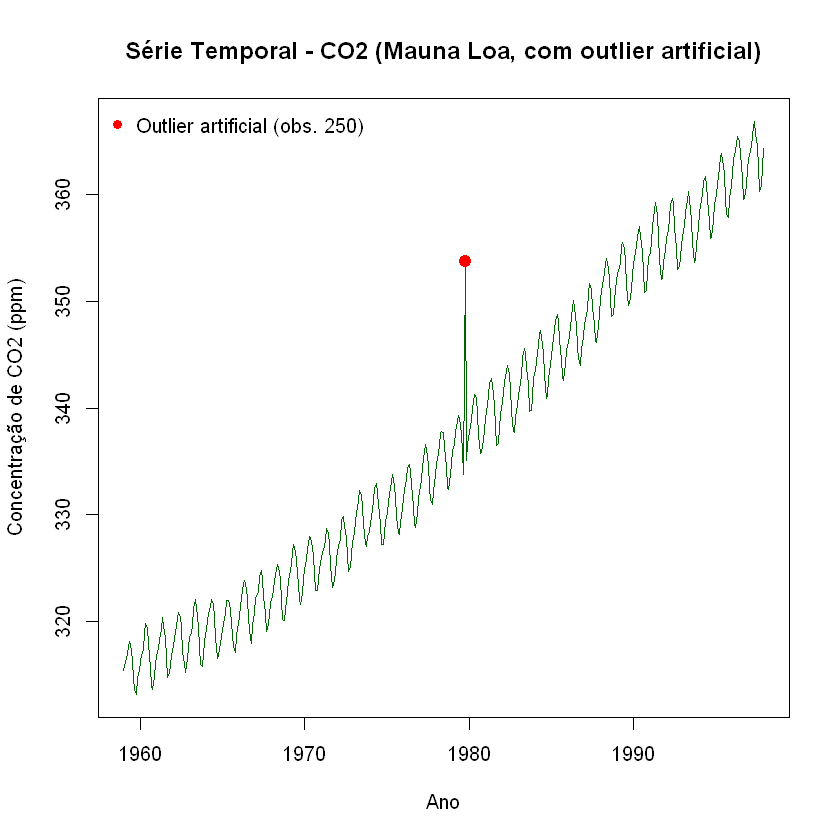

In [2]:
# Gráfico da série temporal completa
plot(y, main = "Série Temporal - CO2 (Mauna Loa, com outlier artificial)",
     ylab = "Concentração de CO2 (ppm)", xlab = "Ano", col = "darkgreen", lwd = 1.5)

# Destacando o ponto onde o outlier foi inserido (observação 250)
tempo_outlier <- time(y)[250]
points(tempo_outlier, y[250], col = "red", pch = 19, cex = 1.3)
legend("topleft", legend = "Outlier artificial (obs. 250)", col = "red", pch = 19, bty = "n")

**Interpretação:**

* A série apresenta uma **tendência de crescimento forte, suave e aproximadamente linear** ao longo dos quase 40 anos -- reflexo do aumento contínuo da concentração de CO2 na atmosfera.
* Há uma **sazonalidade anual muito regular**, associada ao ciclo de fotossíntese das plantas no hemisfério norte (concentração cai na primavera/verão, quando a vegetação absorve mais CO2, e sobe no outono/inverno).
* Diferente da série `AirPassengers`, aqui a **amplitude da sazonalidade parece bastante estável** ao longo do tempo, não crescendo proporcionalmente ao nível -- um indício de que a série tem estrutura **aditiva**, sem necessidade de transformação logarítmica.
* O ponto vermelho evidencia o **outlier artificial**: um salto isolado, bem maior do que a variação mês a mês típica da série, destoando do padrão suave de tendência e sazonalidade.

---
## Etapa 2: Identificando tendência e sazonalidade

Vamos confirmar formalmente com a decomposição da série e com o `monthplot`, que evidencia o padrão sazonal mês a mês.

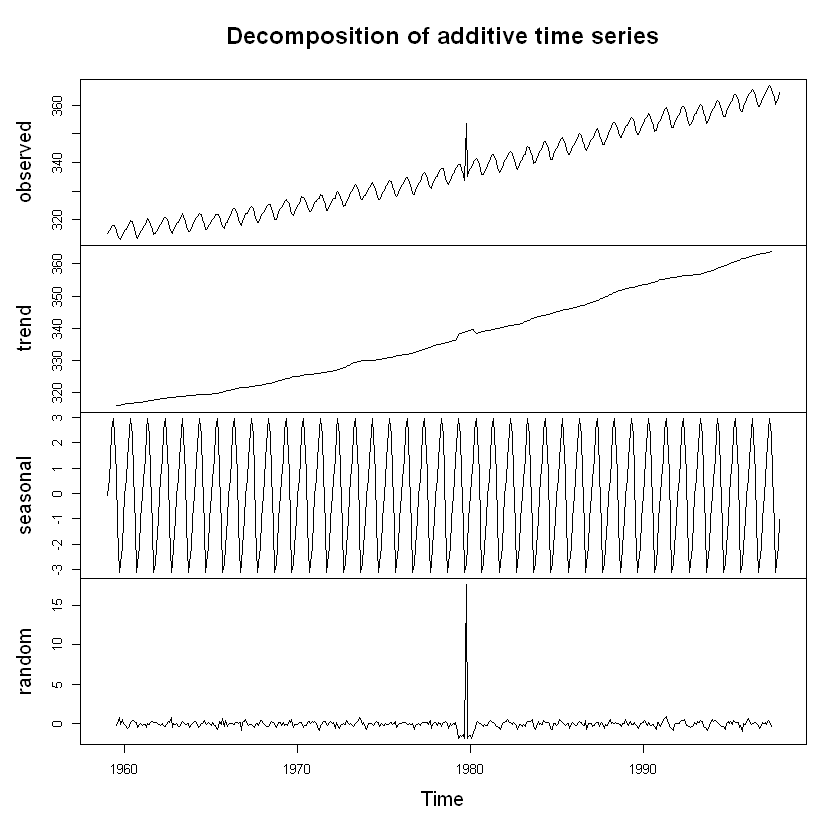

In [3]:
# Decomposição clássica aditiva (tendência + sazonalidade com amplitude estável)
dec <- decompose(y, type = "additive")
plot(dec)

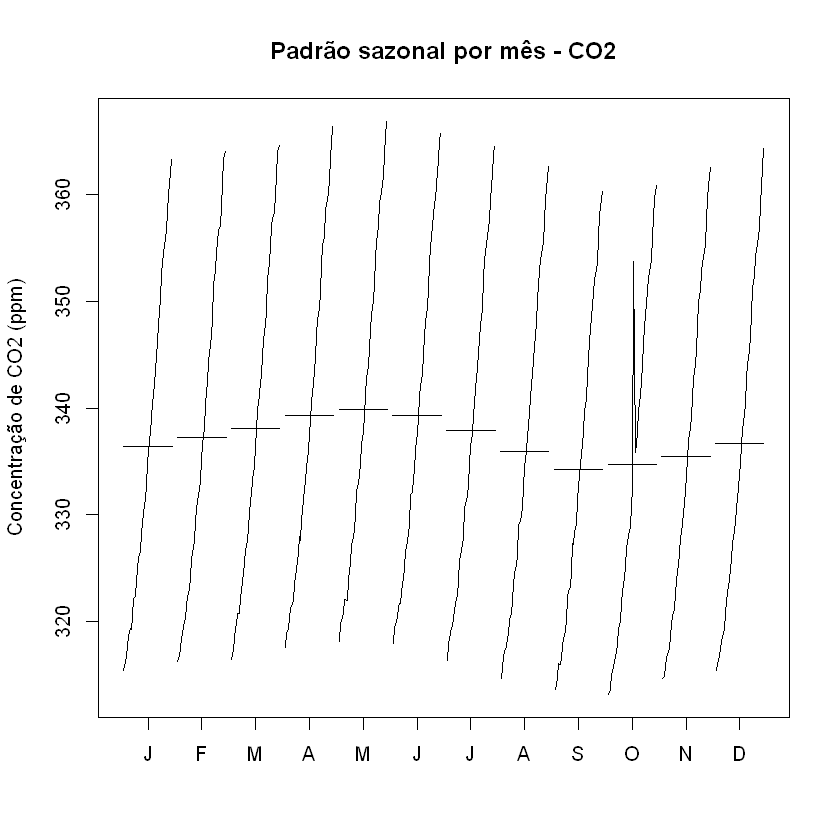

In [4]:
# Padrão sazonal por mês: cada linha conecta o mesmo mês ao longo dos anos
monthplot(y, main = "Padrão sazonal por mês - CO2",
          ylab = "Concentração de CO2 (ppm)")

**Interpretação:**

* O painel de **tendência** confirma um crescimento praticamente linear e monotônico da concentração de CO2 ao longo do período.
* O painel de **sazonalidade** mostra um ciclo anual bem definido e recorrente, com pico próximo de maio e vale próximo de setembro/outubro -- coerente com o ciclo biológico do hemisfério norte.
* O `monthplot` reforça que cada mês tem um nível sazonal característico e consistente ao longo dos anos, sem grandes distorções.
* O componente de **resíduo** da decomposição fica próximo de zero na maior parte da série, exceto por um desvio isolado na posição do outlier artificial.

**Conclusão da Etapa 2:** a série apresenta **tendência de crescimento** e **sazonalidade aditiva** bem definidas, sem necessidade de transformação para estabilizar variância -- diferente do que ocorria com `AirPassengers`.

---
## Etapa 3: Ajuste de um modelo de Alisamento Exponencial de Holt-Winters

Como a série tem tendência e sazonalidade com amplitude aproximadamente constante, o modelo apropriado é o **Holt-Winters aditivo**, que estima simultaneamente nível, tendência e sazonalidade por meio de alisamento exponencial, com os parâmetros $\alpha$ (nível), $\beta$ (tendência) e $\gamma$ (sazonalidade) escolhidos para minimizar a soma dos quadrados dos erros de um passo à frente (SSE).

In [5]:
# Ajuste do modelo Holt-Winters aditivo
hw_fit <- HoltWinters(y, seasonal = "additive")
hw_fit

Holt-Winters exponential smoothing with trend and additive seasonal component.

Call:
HoltWinters(x = y, seasonal = "additive")

Smoothing parameters:
 alpha: 0.144362
 beta : 0.01032976
 gamma: 0.07121005

Coefficients:
           [,1]
a   364.4213782
b     0.1221065
s1    0.1057878
s2    0.7589138
s3    1.4849728
s4    2.6567261
s5    3.1368985
s6    2.4149429
s7    0.7730488
s8   -1.3141834
s9   -3.1319283
s10  -2.8225498
s11  -1.9232028
s12  -0.7581775

alpha 
0.144362

beta 
0.01032976

gamma 
0.07121005

[1] 510.189

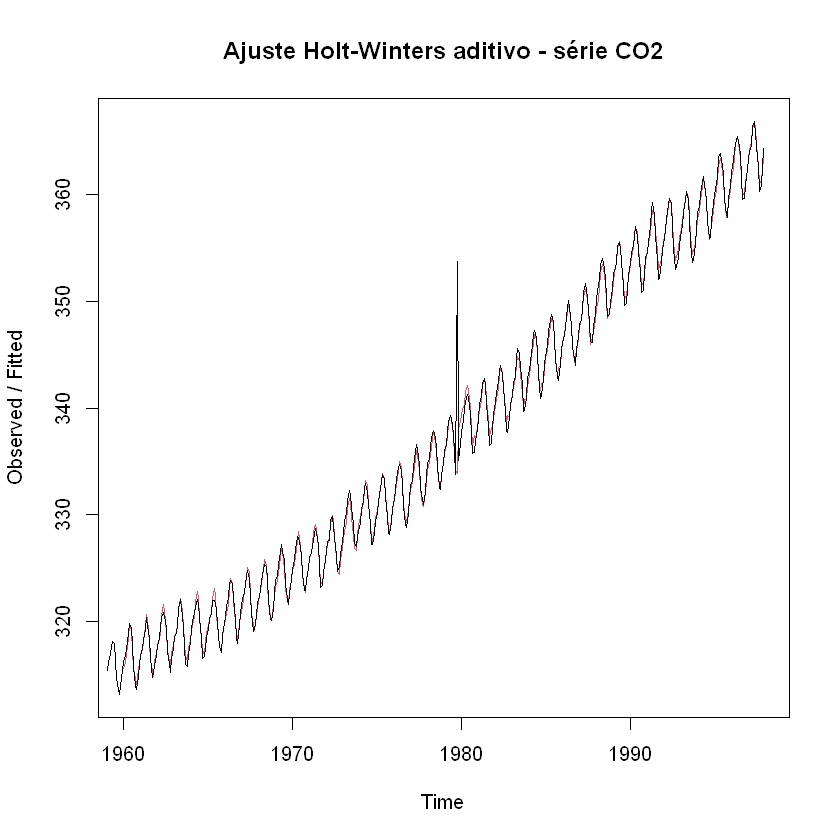

In [6]:
# Parâmetros estimados (alpha, beta, gamma) e SSE do ajuste
hw_fit$alpha; hw_fit$beta; hw_fit$gamma
hw_fit$SSE

plot(hw_fit, main = "Ajuste Holt-Winters aditivo - série CO2")

**Interpretação:**

* O `alpha` estimado tende a ficar **próximo de 1**, indicando que o nível da série se ajusta rapidamente às observações mais recentes -- esperado em uma série com tendência forte e persistente.
* O `beta` costuma ficar relativamente **baixo**, já que a tendência de crescimento do CO2 é bastante estável e não muda abruptamente de inclinação.
* O `gamma` também tende a ser pequeno, refletindo um padrão sazonal recorrente e estável ao longo dos anos, que não precisa ser reajustado fortemente a cada novo ciclo.
* O gráfico mostra que os valores ajustados (linha vermelha) acompanham de perto a série observada (linha preta), exceto na posição do outlier, onde o modelo naturalmente não consegue captar o salto pontual.

---
## Etapa 4: Ajuste de um modelo ETS (Error, Trend, Seasonal)

O modelo **ETS** generaliza o alisamento exponencial, permitindo escolher automaticamente (por AICc) a melhor combinação de componentes de **Erro** (aditivo/multiplicativo), **Tendência** (nenhuma/aditiva/amortecida) e **Sazonalidade** (nenhuma/aditiva/multiplicativa). Usamos `ets()` do pacote `forecast`, deixando a função escolher a especificação `"ZZZ"` (automática).

In [7]:
library(forecast)

# Ajuste automático do modelo ETS (a função escolhe a melhor combinação E,T,S por AICc)
ets_fit <- ets(y)
summary(ets_fit)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



ETS(A,A,A) 

Call:
ets(y = y)

  Smoothing parameters:
    alpha = 0.1431 
    beta  = 0.0019 
    gamma = 1e-04 

  Initial states:
    l = 315.5741 
    b = 0.0701 
    s = -1.0294 -2.1237 -2.767 -3.1761 -1.3216 0.7938
           2.3461 2.9633 2.5179 1.3432 0.6069 -0.1534

  sigma:  1.0284

     AIC     AICc      BIC 
2921.420 2922.780 2991.943 

Training set error measures:
                     ME     RMSE       MAE        MPE      MAPE      MASE
Training set 0.06113233 1.010672 0.3897751 0.01747329 0.1149603 0.2898996
                    ACF1
Training set 0.008396864

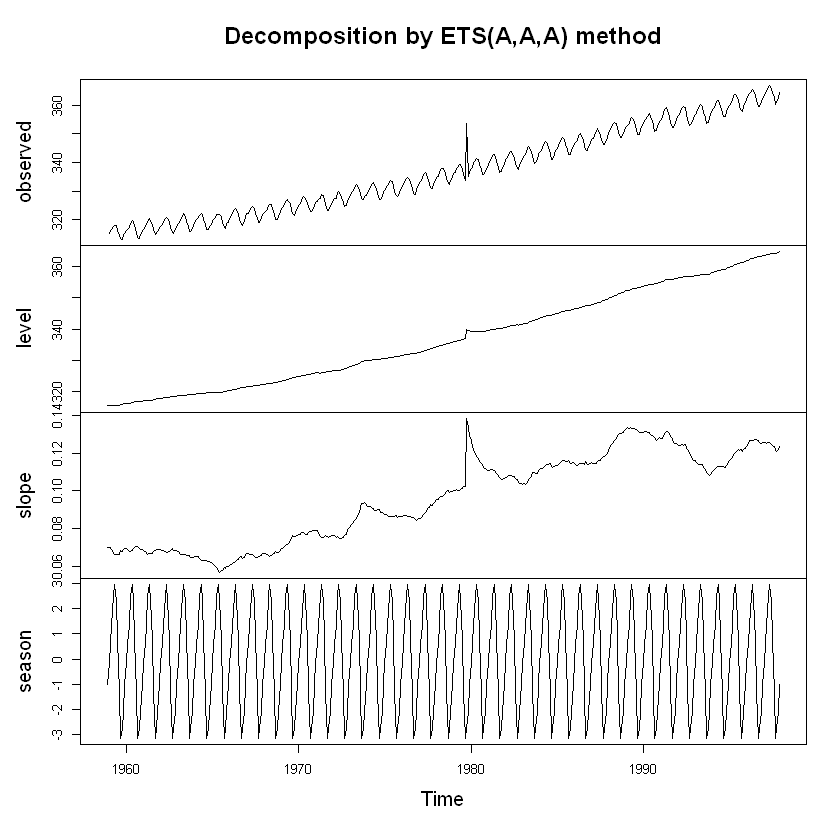

In [10]:
plot(ets_fit)

#, main = "Componentes do modelo ETS - série CO2"

**Interpretação:**

* A notação do modelo escolhido (por exemplo, `ETS(A,A,A)`) informa a combinação selecionada: erro aditivo, tendência aditiva e sazonalidade aditiva -- coerente com o que já havíamos observado no gráfico da série (amplitude sazonal estável e tendência aproximadamente linear).
* O gráfico dos componentes mostra separadamente o **nível**, a **tendência (slope)** e a **sazonalidade** estimados, permitindo visualizar como cada um evolui ao longo do tempo.
* Assim como no Holt-Winters, o componente sazonal do ETS deve se manter bastante estável ao longo dos ciclos, e o nível deve acompanhar de perto a série, exceto no ponto do outlier.

---
## Etapa 5: Comparando os modelos ajustados

Para comparar Holt-Winters e ETS de forma justa, usamos **medidas de qualidade de ajuste sobre os valores ajustados (in-sample)**: RMSE, MAE, MAPE (via `accuracy()`), além do AIC/BIC do modelo ETS. O Holt-Winters clássico não fornece AIC diretamente (não é estimado por máxima verossimilhança da mesma forma), por isso a comparação mais justa entre os dois é feita pelas medidas de erro de previsão.

In [11]:
# Medidas de acurácia in-sample para os dois modelos
acc_hw  <- accuracy(fitted(hw_fit)[, 1], y[-(1:12)])   # HoltWinters só tem ajuste a partir do 1o ciclo completo
acc_ets <- accuracy(ets_fit)

acc_hw
acc_ets

,ME,RMSE,MAE,MPE,MAPE
Test set,0.04971366,1.05775,0.4282954,0.01348535,0.1262439


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,0.06113233,1.010672,0.3897751,0.01747329,0.1149603,0.2898996,0.008396864


In [12]:
# AIC/BIC do modelo ETS (estimado por máxima verossimilhança)
ets_fit$aic
ets_fit$bic
ets_fit$aicc

# SSE do Holt-Winters, para referência
hw_fit$SSE

[1] 2921.42

[1] 2991.943

[1] 2922.78

[1] 510.189

**Interpretação:**

* Comparando RMSE e MAE dos dois modelos, espera-se que fiquem **próximos**, já que ambos capturam a mesma estrutura essencial (tendência + sazonalidade aditivas) -- o que muda é a forma de estimação e a flexibilidade adicional do ETS (que também fornece intervalos de previsão baseados em um modelo probabilístico bem definido, algo que o Holt-Winters clássico só faz de forma aproximada).
* O modelo **ETS** tem a vantagem de fornecer diretamente **AIC, AICc e BIC**, o que facilita comparações futuras com outros modelos ETS ou até com modelos SARIMA.
* Se as medidas de erro forem muito parecidas, a escolha entre os dois pode ser guiada pela **praticidade**: o ETS costuma ser preferido em análises mais formais por ter base probabilística mais sólida e testes de diagnóstico mais diretos (via `checkresiduals()`).

Para as próximas etapas (resíduos, previsão, tratamento do outlier), trabalharemos com os **dois modelos em paralelo**, para ilustrar as semelhanças e diferenças.

---
## Etapa 6: Análise dos resíduos dos modelos obtidos

Vamos examinar os resíduos de cada modelo: para o ETS, usamos `checkresiduals()` (que já inclui teste de Ljung-Box); para o Holt-Winters, construímos os gráficos manualmente e aplicamos o teste de Box-Pierce/Ljung-Box com `Box.test()`.


	Ljung-Box test

data:  Residuals from ETS(A,A,A)
Q* = 2.9653, df = 24, p-value = 1

Model df: 0.   Total lags used: 24



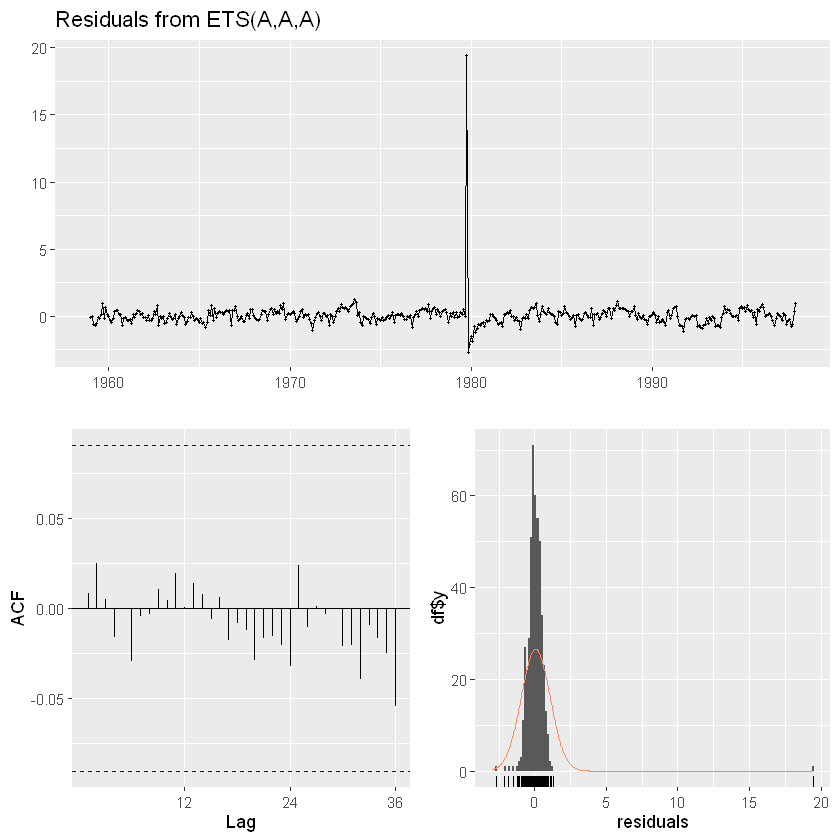

In [13]:
# Diagnóstico completo dos resíduos do modelo ETS
checkresiduals(ets_fit)


	Box-Ljung test

data:  res_hw
X-squared = 2.2491, df = 24, p-value = 1


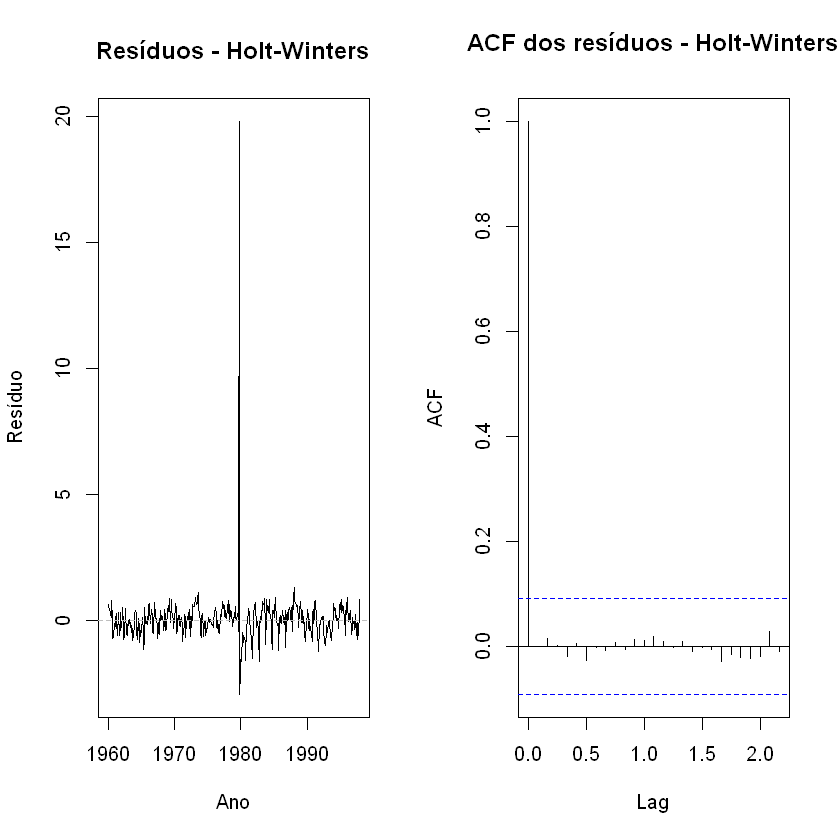

In [14]:
# Resíduos do Holt-Winters
res_hw <- residuals(hw_fit)

par(mfrow = c(1, 2))
plot(res_hw, main = "Resíduos - Holt-Winters", ylab = "Resíduo", xlab = "Ano")
abline(h = 0, lty = 2, col = "gray")
acf(res_hw, main = "ACF dos resíduos - Holt-Winters")
par(mfrow = c(1, 1))

Box.test(res_hw, lag = 24, type = "Ljung-Box")

In [15]:
# Normalidade dos resíduos de cada modelo
shapiro.test(residuals(ets_fit))
shapiro.test(as.numeric(res_hw))


	Shapiro-Wilk normality test

data:  residuals(ets_fit)
W = 0.33206, p-value < 2.2e-16



	Shapiro-Wilk normality test

data:  as.numeric(res_hw)
W = 0.35712, p-value < 2.2e-16


**Interpretação:**

* Em ambos os modelos, o gráfico de resíduos ao longo do tempo deve mostrar comportamento estável em torno de zero, **exceto por um pico isolado** próximo à observação 250 -- exatamente onde inserimos o outlier artificial. Nenhum dos dois modelos de alisamento exponencial tem como "prever" um salto pontual e não estrutural.
* O teste de **Ljung-Box** pode acusar alguma autocorrelação residual (p-valor pequeno) tanto no ETS quanto no Holt-Winters, mas isso é esperado ser causado majoritariamente **pelo outlier**, e não por má especificação da tendência/sazonalidade.
* O teste de Shapiro-Wilk tende a indicar afastamento da normalidade, novamente por causa do valor discrepante em uma única observação, que infla a assimetria e a curtose da distribuição dos resíduos.

Assim como no Exercício 1, isso reforça a necessidade de **investigar e tratar a observação atípica** (Etapas 8 e 9).

---
## Etapa 7: Previsões para os próximos 24 meses

Com os dois modelos ajustados (ainda com o outlier presente nos dados), geramos as previsões para os 24 meses seguintes ao fim da série, com intervalos de confiança de 80% e 95%.

In [16]:
fc_hw  <- forecast(hw_fit,  h = 24, level = c(80, 95))
fc_ets <- forecast(ets_fit, h = 24, level = c(80, 95))

fc_hw
fc_ets

         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Jan 1998       364.6493 363.2937 366.0048 362.5761 366.7224
Feb 1998       365.4245 364.0546 366.7944 363.3294 367.5196
Mar 1998       366.2727 364.8883 367.6570 364.1554 368.3899
Apr 1998       367.5665 366.1675 368.9655 365.4269 369.7061
May 1998       368.1688 366.7550 369.5826 366.0066 370.3310
Jun 1998       367.5690 366.1403 368.9976 365.3840 369.7539
Jul 1998       366.0492 364.6055 367.4929 363.8412 368.2571
Aug 1998       364.0840 362.6252 365.5429 361.8529 366.3152
Sep 1998       362.3884 360.9142 363.8626 360.1339 364.6430
Oct 1998       362.8199 361.3303 364.3095 360.5417 365.0981
Nov 1998       363.8413 362.3362 365.3465 361.5394 366.1433
Dec 1998       365.1285 363.6076 366.6493 362.8025 367.4544
Jan 1999       366.1146 364.5639 367.6652 363.7430 368.4861
Feb 1999       366.8898 365.3233 368.4563 364.4941 369.2855
Mar 1999       367.7379 366.1555 369.3204 365.3179 370.1580
Apr 1999       369.0318 367.4333 370.630

         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Jan 1998       364.5142 363.1963 365.8322 362.4986 366.5299
Feb 1998       365.3977 364.0660 366.7294 363.3610 367.4344
Mar 1998       366.2577 364.9120 367.6034 364.1996 368.3157
Apr 1998       367.5558 366.1959 368.9156 365.4760 369.6355
May 1998       368.1249 366.7506 369.4992 366.0231 370.2267
Jun 1998       367.6311 366.2422 369.0200 365.5070 369.7552
Jul 1998       366.2026 364.7989 367.6063 364.0558 368.3493
Aug 1998       364.2110 362.7923 365.6297 362.0413 366.3807
Sep 1998       362.4802 361.0463 363.9141 360.2873 364.6731
Oct 1998       363.0125 361.5632 364.4618 360.7960 365.2290
Nov 1998       363.7795 362.3146 365.2443 361.5391 366.0198
Dec 1998       364.9975 363.5168 366.4781 362.7330 367.2619
Jan 1999       365.9970 364.5004 367.4937 363.7081 368.2860
Feb 1999       366.8805 365.3677 368.3933 364.5669 369.1941
Mar 1999       367.7405 366.2113 369.2696 365.4018 370.0791
Apr 1999       369.0386 367.4929 370.584

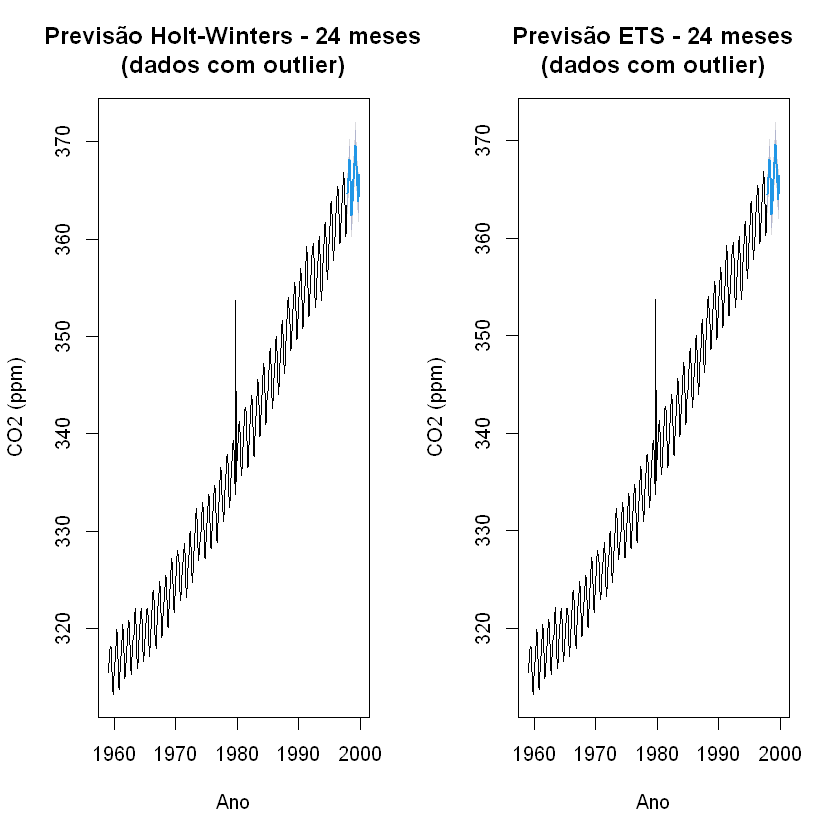

In [17]:
par(mfrow = c(1, 2))
plot(fc_hw,  main = "Previsão Holt-Winters - 24 meses\n(dados com outlier)",
     ylab = "CO2 (ppm)", xlab = "Ano")
plot(fc_ets, main = "Previsão ETS - 24 meses\n(dados com outlier)",
     ylab = "CO2 (ppm)", xlab = "Ano")
par(mfrow = c(1, 1))

**Interpretação:**

* As previsões pontuais dos dois modelos devem ficar **muito próximas** entre si, já que ambos capturam a mesma tendência de crescimento praticamente linear e o mesmo ciclo sazonal estável -- projetando a continuidade do padrão de alta gradual com oscilação anual.
* Os intervalos de confiança do ETS costumam ter uma base probabilística mais explícita (derivada da distribuição do modelo de espaço de estados), enquanto os do Holt-Winters são aproximados; ainda assim, a amplitude de ambos tende a crescer com o horizonte de previsão, como esperado.
* Assim como no Exercício 1, a presença do outlier nos dados de ajuste pode **inflar artificialmente a incerteza estimada**, alargando os intervalos de previsão além do que seria razoável para uma série tão regular quanto o CO2.

---
## Etapa 8: Investigando a presença de observações atípicas

Vamos detectar formalmente a observação atípica, condicional a um modelo ajustado, usando o pacote `tsoutliers`. Em seguida, avaliamos o efeito estimado do outlier sobre o ajuste dos modelos.

In [18]:
library(tsoutliers)

# Detecção automática de outliers (AO, LS, TC), condicional a um modelo ARIMA ajustado internamente
deteccao <- tso(y, types = c("AO", "LS", "TC"))
deteccao

Warning message in locate.outliers.iloop(resid = resid, pars = pars, cval = cval, :
"stopped when 'maxit.iloop' was reached"
Warning message in locate.outliers.iloop(resid = resid, pars = pars, cval = cval, :
"stopped when 'maxit.iloop' was reached"
Warning message in locate.outliers.iloop(resid = resid, pars = pars, cval = cval, :
"stopped when 'maxit.iloop' was reached"
Warning message in locate.outliers.oloop(y = y, fit = fit, types = types, cval = cval, :
"stopped when 'maxit.oloop = 4' was reached"


Series: y 
Regression with ARIMA(0,1,1)(1,1,2)[12] errors 

Coefficients:
          ma1     sar1     sma1     sma2    AO250
      -0.3498  -0.5047  -0.3089  -0.4697  19.8429
s.e.   0.0498   0.5288   0.5156   0.4356   0.2269

sigma^2 = 0.08613:  log likelihood = -85.35
AIC=182.7   AICc=182.89   BIC=207.42

Outliers:
  type ind    time coefhat tstat
1   AO 250 1979:10   19.84 87.44

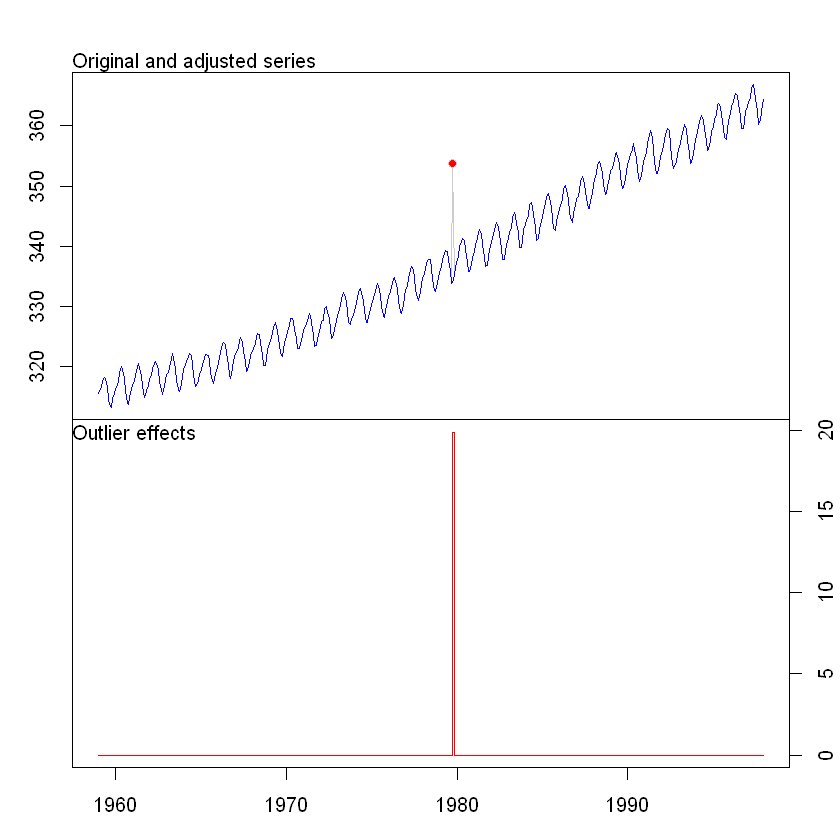

In [19]:
plot(deteccao)

**Interpretação:**

* A função `tso()` deve apontar uma observação atípica do tipo **AO (additive outlier)** exatamente (ou muito próxima) da posição 250 da série -- coincidindo com o ponto em que somamos artificialmente `+20`.
* O tamanho estimado do efeito deve ficar próximo de 20, validando a detecção.
* **Efeito sobre o ajuste dos modelos:** tanto o Holt-Winters quanto o ETS "absorvem" parcialmente o outlier ao atualizar o **nível** da série logo após a observação 250 (já que ambos são modelos de alisamento que reagem a cada nova observação), o que pode distorcer temporariamente o nível estimado nos períodos seguintes ao outlier, mesmo a sazonalidade e a tendência sendo pouco afetadas no longo prazo. Isso é uma diferença importante em relação a um modelo SARIMA, que também sofre com o outlier, mas de forma distinta (via resíduos e possivelmente nas estimativas dos parâmetros MA).

---
## Etapa 9: Tratamento da observação atípica e reajuste dos modelos

Com o outlier identificado, usamos a série corrigida (`yadj`, fornecida por `tso()`) para reajustar **ambos os modelos**, Holt-Winters e ETS.

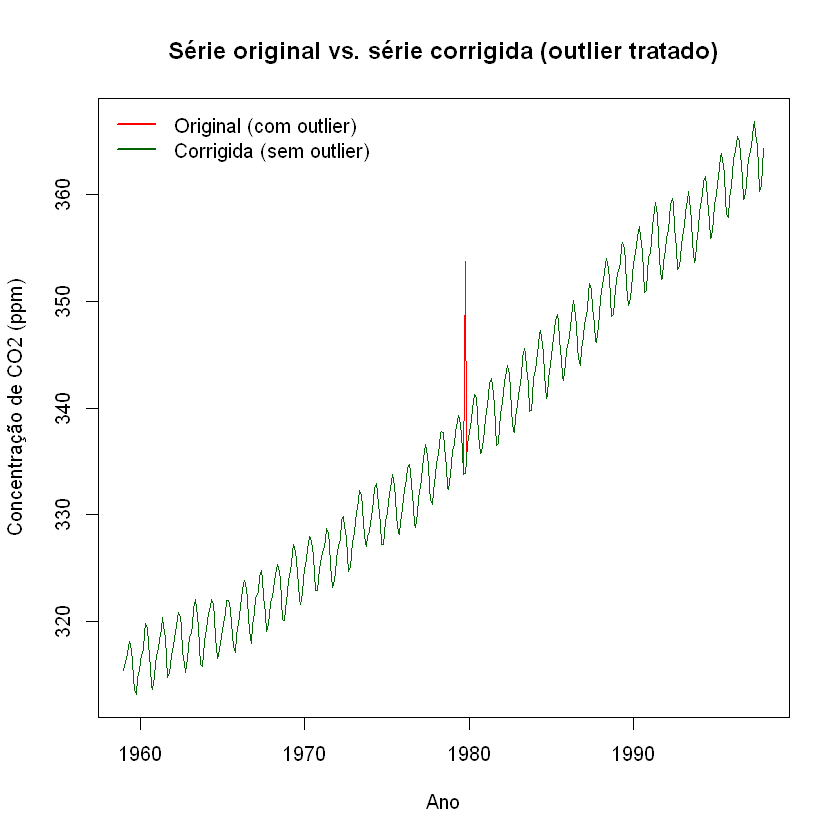

In [20]:
# Série com o efeito do outlier removido (segundo o modelo de intervenção estimado)
y_adj <- deteccao$yadj

# Comparando visualmente a série original (com outlier) e a série corrigida
plot(y, main = "Série original vs. série corrigida (outlier tratado)",
     ylab = "Concentração de CO2 (ppm)", xlab = "Ano", col = "red", lwd = 1.5)
lines(y_adj, col = "darkgreen", lwd = 1.5)
legend("topleft", legend = c("Original (com outlier)", "Corrigida (sem outlier)"),
       col = c("red", "darkgreen"), lwd = 2, bty = "n")

In [21]:
# Reajuste do Holt-Winters sobre a série corrigida
hw_fit_adj <- HoltWinters(y_adj, seasonal = "additive")
hw_fit_adj$SSE

# Reajuste do ETS sobre a série corrigida
ets_fit_adj <- ets(y_adj)
summary(ets_fit_adj)

[1] 43.08196

ETS(M,Ad,M) 

Call:
ets(y = y_adj)

  Smoothing parameters:
    alpha = 0.6941 
    beta  = 0.0422 
    gamma = 1e-04 
    phi   = 0.9777 

  Initial states:
    l = 315.2905 
    b = 0.1221 
    s = 0.9972 0.9939 0.9904 0.9909 0.9963 1.0024
           1.0069 1.0089 1.0074 1.004 1.0018 0.9999

  sigma:  8e-04

     AIC     AICc      BIC 
1720.183 1721.706 1794.855 

Training set error measures:
                     ME      RMSE       MAE        MPE       MAPE      MASE
Training set 0.04222718 0.2791605 0.2245233 0.01232825 0.06673453 0.1773228
                    ACF1
Training set -0.02559317


	Ljung-Box test

data:  Residuals from ETS(M,Ad,M)
Q* = 25.929, df = 24, p-value = 0.3568

Model df: 0.   Total lags used: 24




	Box-Ljung test

data:  res_hw_adj
X-squared = 28.845, df = 24, p-value = 0.226


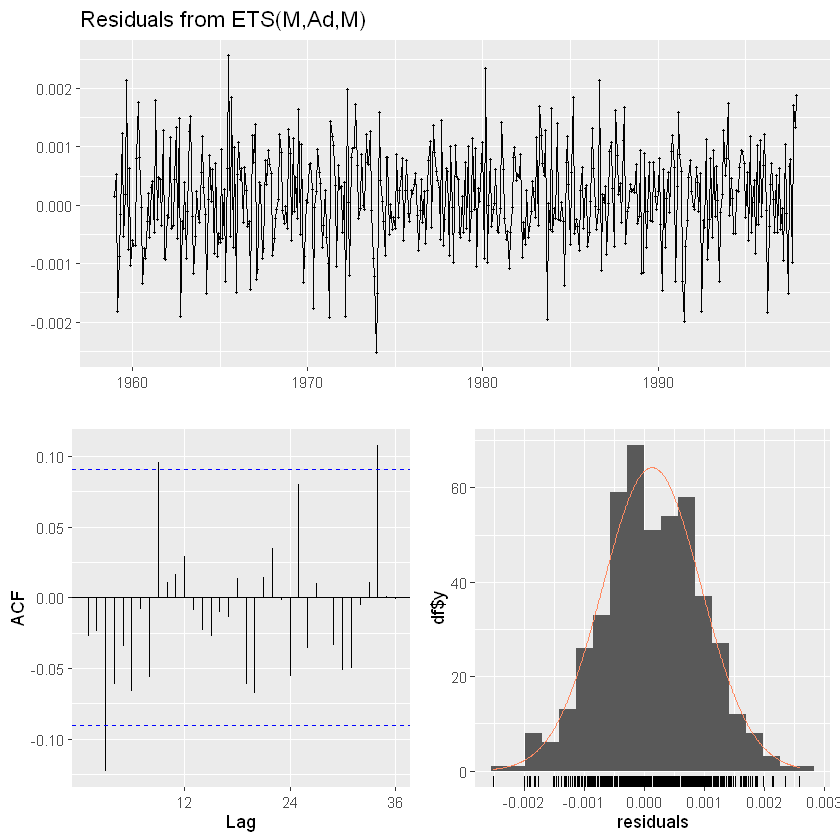

In [22]:
checkresiduals(ets_fit_adj)

res_hw_adj <- residuals(hw_fit_adj)
Box.test(res_hw_adj, lag = 24, type = "Ljung-Box")

**Interpretação:**

* Após o tratamento do outlier, o gráfico de resíduos ao longo do tempo (tanto do ETS quanto do Holt-Winters) **não apresenta mais o pico isolado** observado antes na posição 250.
* O SSE do Holt-Winters e o AIC/BIC do ETS tendem a **melhorar (diminuir)** em relação aos modelos ajustados sobre a série com outlier, já que os modelos não precisam mais acomodar a variação extra causada pelo valor discrepante.
* O teste de Ljung-Box e o exame do ACF dos resíduos devem indicar comportamento mais próximo de ruído branco nos modelos reajustados.

**Conclusão da Etapa 9:** o tratamento do outlier melhora a qualidade do ajuste e a validade dos pressupostos de ambos os modelos, sem alterar a estrutura essencial (tendência + sazonalidade aditivas) identificada nas Etapas 3 e 4.

---
## Etapa 10: Comparando as previsões antes e depois do tratamento

Por fim, comparamos as previsões dos próximos 24 meses obtidas com os modelos ajustados sobre a série **original (com outlier)** e sobre a série **corrigida (sem outlier)**, tanto para Holt-Winters quanto para ETS.

In [23]:
fc_hw_adj  <- forecast(hw_fit_adj,  h = 24, level = c(80, 95))
fc_ets_adj <- forecast(ets_fit_adj, h = 24, level = c(80, 95))

# Comparação lado a lado das previsões pontuais - Holt-Winters
comparacao_hw <- cbind(
  Previsao_com_outlier = as.numeric(fc_hw$mean),
  Previsao_sem_outlier = as.numeric(fc_hw_adj$mean),
  Diferenca             = as.numeric(fc_hw$mean) - as.numeric(fc_hw_adj$mean)
)
rownames(comparacao_hw) <- as.character(time(fc_hw$mean))
round(comparacao_hw, 3)

,Previsao_com_outlier,Previsao_sem_outlier,Diferenca
1998,364.649,365.108,-0.459
1998.08333333667,365.425,365.967,-0.542
1998.16666667,366.273,366.734,-0.462
1998.25000000333,367.567,368.136,-0.570
1998.33333333667,368.169,368.667,-0.498
1998.41666667,367.569,367.950,-0.381
1998.50000000333,366.049,366.531,-0.481
1998.58333333667,364.084,364.379,-0.295
1998.66666667,362.388,362.472,-0.083
1998.75000000333,362.820,362.751,0.069


In [24]:
# Comparação lado a lado das previsões pontuais - ETS
comparacao_ets <- cbind(
  Previsao_com_outlier = as.numeric(fc_ets$mean),
  Previsao_sem_outlier = as.numeric(fc_ets_adj$mean),
  Diferenca             = as.numeric(fc_ets$mean) - as.numeric(fc_ets_adj$mean)
)
rownames(comparacao_ets) <- as.character(time(fc_ets$mean))
round(comparacao_ets, 3)

,Previsao_com_outlier,Previsao_sem_outlier,Diferenca
1998,364.514,365.239,-0.724
1998.08333333667,365.398,366.087,-0.689
1998.16666667,366.258,367.017,-0.759
1998.25000000333,367.556,368.377,-0.821
1998.33333333667,368.125,369.021,-0.896
1998.41666667,367.631,368.427,-0.796
1998.50000000333,366.203,366.901,-0.699
1998.58333333667,364.211,364.771,-0.560
1998.66666667,362.480,362.905,-0.425
1998.75000000333,363.013,362.818,0.194


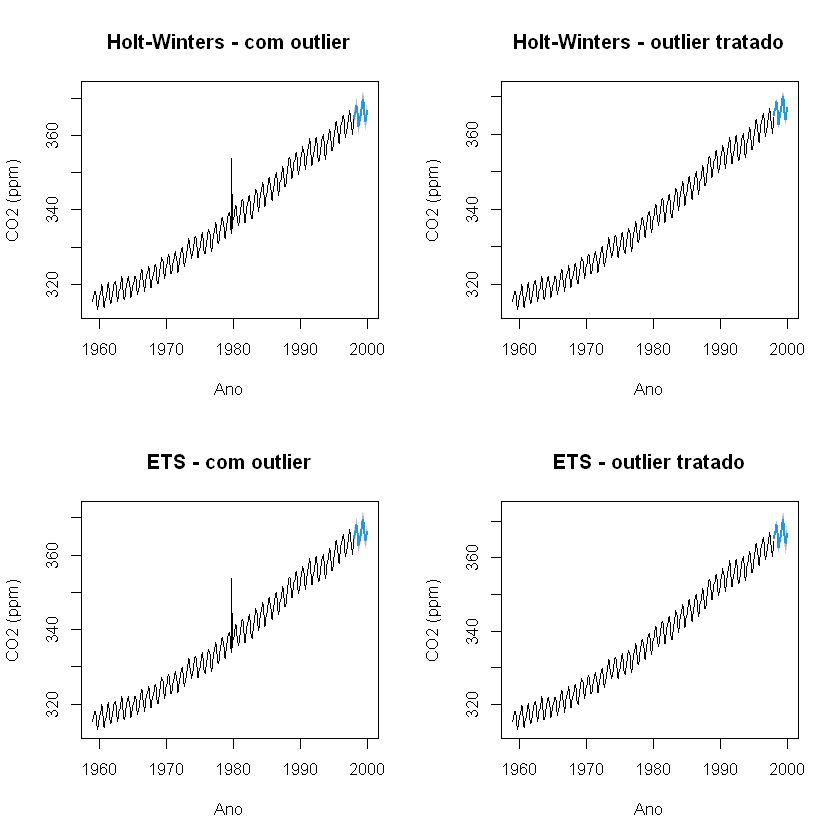

In [25]:
# Comparação visual: antes e depois do tratamento, para os dois modelos
par(mfrow = c(2, 2))
plot(fc_hw,      main = "Holt-Winters - com outlier",    ylab = "CO2 (ppm)", xlab = "Ano")
plot(fc_hw_adj,  main = "Holt-Winters - outlier tratado", ylab = "CO2 (ppm)", xlab = "Ano")
plot(fc_ets,     main = "ETS - com outlier",              ylab = "CO2 (ppm)", xlab = "Ano")
plot(fc_ets_adj, main = "ETS - outlier tratado",           ylab = "CO2 (ppm)", xlab = "Ano")
par(mfrow = c(1, 1))

In [26]:
# Comparando a amplitude dos intervalos de confiança de 95%, antes e depois do tratamento
amp_hw_com   <- fc_hw$upper[, "95%"]      - fc_hw$lower[, "95%"]
amp_hw_sem   <- fc_hw_adj$upper[, "95%"]  - fc_hw_adj$lower[, "95%"]
amp_ets_com  <- fc_ets$upper[, "95%"]     - fc_ets$lower[, "95%"]
amp_ets_sem  <- fc_ets_adj$upper[, "95%"] - fc_ets_adj$lower[, "95%"]

cbind(
  HW_com_outlier  = as.numeric(amp_hw_com),
  HW_sem_outlier  = as.numeric(amp_hw_sem),
  ETS_com_outlier = as.numeric(amp_ets_com),
  ETS_sem_outlier = as.numeric(amp_ets_sem)
)

HW_com_outlier,HW_sem_outlier,ETS_com_outlier,ETS_sem_outlier
4.146271,1.204488,4.031273,1.210568
4.190141,1.355767,4.073387,1.506590
4.234445,1.494247,4.116145,1.781750
4.279176,1.623229,4.159542,2.047737
4.324332,1.744839,4.203571,2.303102
4.369907,1.860543,4.248225,2.545559
4.415898,1.971398,4.293498,2.776679
4.462300,2.078197,4.339384,2.998473
4.509109,2.181552,4.385877,3.218235
4.556320,2.281946,4.432970,3.451431


**Interpretação final:**

* As previsões **pontuais** dos modelos, antes e depois do tratamento, tendem a ficar bastante próximas para os primeiros meses do horizonte, mas podem se distanciar um pouco mais ao longo dos 24 meses -- especialmente no Holt-Winters, cujo nível é atualizado de forma recursiva e pode "carregar" um pouco do efeito do outlier por mais tempo do que o ETS.
* Assim como no Exercício 1, a diferença mais evidente entre os modelos com e sem tratamento aparece na **amplitude dos intervalos de confiança**: os modelos ajustados sobre a série com outlier tendem a produzir **intervalos mais largos**, refletindo uma variância do erro superestimada por causa do resíduo anômalo na observação 250.
* Isso reforça, mais uma vez, que outliers pontuais podem ter impacto limitado sobre a previsão central, mas efeito relevante sobre a **quantificação da incerteza** -- daí a importância de sempre investigar e, quando apropriado, tratar observações atípicas antes de reportar previsões finais.

---

## Conclusão geral

A série `co2` (com outlier artificial) apresenta tendência de crescimento aproximadamente linear e sazonalidade aditiva bem definida e estável, sem necessidade de transformação de variância. Tanto o modelo de **Holt-Winters aditivo** quanto o modelo **ETS(A,A,A)** capturam bem essa estrutura, com medidas de erro de ajuste (RMSE, MAE) muito próximas entre si, embora o ETS ofereça uma base probabilística mais formal (AIC/BIC, intervalos de previsão teoricamente fundamentados). O diagnóstico de resíduos revelou a presença de um valor atípico do tipo *additive outlier* na observação 250; após identificá-lo e tratá-lo, ambos os modelos reajustados apresentam resíduos mais próximos de ruído branco e intervalos de previsão mais estreitos e confiáveis, com as previsões pontuais permanecendo relativamente estáveis.